# 5.6a Eksperimen Gabungan 204 Fitur — Varian LINEAR

Pemetaan tugas PSD: **menggabungkan 3 polutan = 204 kolom** (68 NO2 + 68 SO2 + 68 CO, interpolasi **linier**) → **reduksi dimensi 204 → 74 → 37** → **hasil clustering tiap dimensi** → **eksperimen cluster terbaik via silhouette** → peta di notebook 5.7.

Sumber sudah gabungan 3 polutan (`data/ekstraksi_fitur_linear.csv`, 36 baris × 204 fitur, missing=0), sehingga Fase 0 hanya menormalisasi kunci daerah + agregasi mean observasi ganda (Kamal & Kwanyar, 36 → 34 daerah). Koreksi atas notebook 5.6 lama yang memakai `data/downloads/ekstraksi fitur/ekstraksi_fitur_{co,no2,so2}.csv` (33 daerah lengkap). Catatan: "203" di rumusan tugas = typo untuk **204** (68×3).

Pemenang = **silhouette tertinggi dengan min_size≥2** (tanpa singleton — jujur, karena reduksi 74/37 kolaps menjadi outlier tunggal sehingga skor mentahnya semu tinggi).

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import json
from IPython.display import Image, display

SEED = 42
SRC = "../data/ekstraksi_fitur_linear.csv"
TAG = "linear"
OUT = "../data/processed"
IMG = "../data/images/eksperimen204_linear"
LADDER = [204, 74, 37]
os.makedirs(OUT, exist_ok=True)
os.makedirs(IMG, exist_ok=True)


## Fase 0 — Matriks 204 fitur (kunci daerah + agregasi duplikat)

36 baris → 34 daerah unik (Kamal & Kwanyar diobservasi 2×, diagregasi mean). Komposisi diverifikasi: 68 NO2 + 68 SO2 + 68 CO.

In [2]:
def norm_daerah(s):
    return " ".join(str(s).strip().lower().split())

df = pd.read_csv(SRC)
feat204 = [c for c in df.columns if c not in ("id", "nama", "daerah")]
assert len(feat204) == 204, f"{len(feat204)} fitur, bukan 204!"
pref = pd.Series([c.split("_")[0] for c in feat204]).value_counts().to_dict()
assert pref == {"no2": 68, "so2": 68, "co": 68}, f"komposisi {pref}"
df["key"] = df["daerah"].map(norm_daerah)
dup = df[df.duplicated("key", keep=False)].sort_values("key")
print(f"duplikat (diagregasi mean): {sorted(dup['daerah'].unique().tolist())}")
g = df.groupby("key")
agg = g[feat204].mean()
agg.insert(0, "daerah", g["daerah"].first())
agg = agg.reset_index(drop=True)
print(f"matriks: {len(agg)} daerah x {len(feat204)} fitur, missing={int(agg[feat204].isna().sum().sum())}")
agg[["daerah"] + feat204].to_csv(f"{OUT}/clustering_{TAG}_204.csv", index=False)
print("tersimpan:", f"{OUT}/clustering_{TAG}_204.csv", agg.shape)


duplikat (diagregasi mean): ['Kamal, Bangkalan', 'Kwanyar, Bangkalan']
matriks: 34 daerah x 204 fitur, missing=0
tersimpan: ../data/processed/clustering_linear_204.csv (34, 205)


## Fase 1 — Reduksi bertahap 204 → 74 → 37

Peringkat variansi (dihitung sebelum standardisasi) + `StandardScaler`. `retained_var` = proporsi variansi dipertahankan — inilah "hasil yang ditunjukkan" tiap pemangkasan. Catatan jujur: nilainya ≈1.0 di semua tahap karena variansi didominasi segelintir fitur berskala besar (mis. `ecdf_slope`); pemangkasan variansi mentah praktis tak membuang variansi, sehingga tahap 74/37 tetap rawan kolaps (terbukti di Fase 2).

tahap 204: 204 fitur, retained_var=1.0000
tahap 74: 74 fitur, retained_var=1.0000
tahap 37: 37 fitur, retained_var=1.0000


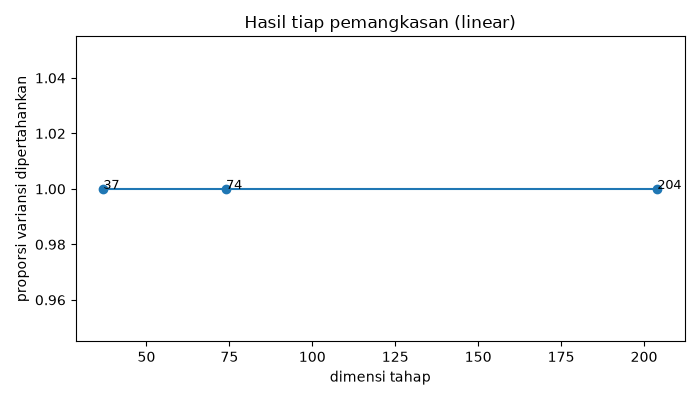

In [3]:
from sklearn.preprocessing import StandardScaler

dfm = pd.read_csv(f"{OUT}/clustering_{TAG}_204.csv")
feat = [c for c in dfm.columns if c != "daerah"]
Xraw = dfm[feat].to_numpy()
var_rank = np.argsort(Xraw.var(axis=0))[::-1]
total_var = float(Xraw.var(axis=0).sum())

lad_rows = []
for d in LADDER:
    keep = sorted(var_rank[:d].tolist())
    cols = [feat[i] for i in keep]
    Xs = StandardScaler().fit_transform(dfm[cols].to_numpy())
    pd.DataFrame(Xs, columns=cols).to_csv(f"{OUT}/X_{TAG}_{d}.csv", index=False)
    retained = float(Xraw[:, var_rank[:d]].var(axis=0).sum() / total_var)
    lad_rows.append({"dimensi": d, "n_fitur": len(cols), "retained_var": round(retained, 4)})
    print(f"tahap {d}: {len(cols)} fitur, retained_var={retained:.4f}")
lad_df = pd.DataFrame(lad_rows)
lad_df.to_csv(f"{OUT}/ladder_{TAG}.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lad_df["dimensi"], lad_df["retained_var"], marker="o")
for _, r in lad_df.iterrows():
    ax.annotate(str(int(r['dimensi'])), (r['dimensi'], r['retained_var']), fontsize=9)
ax.set_xlabel("dimensi tahap"); ax.set_ylabel("proporsi variansi dipertahankan")
ax.set_title(f"Hasil tiap pemangkasan ({TAG})")
fig.tight_layout(); fig.savefig(f"{IMG}/fig_ladder_var.png", dpi=100)
display(Image(filename=f"{IMG}/fig_ladder_var.png"))


## Fase 2 — Grid penuh + cluster terbaik via silhouette

Setiap tahap × k=2..10 (`random_state=42, n_init=10, max_iter=300`) = 27 konfigurasi. Pemenang = silhouette tertinggi dengan **min_size≥2** (tanpa singleton), diteruskan ke 5.7 via `best_config_{TAG}.json` + `labels_best_{TAG}.csv`. Peringkat mentah dilaporkan transparan.

total konfigurasi: 27
 dimensi  k  silhouette     inertia  seed  min_size ukuran_cluster
      37  2    0.497054  977.098992    42         2           2;32
     204  2    0.483846 5693.411376    42         1           33;1
      74  2    0.429449 2032.132413    42         4           4;30
      74  3    0.408712 1583.662838    42         2         2;30;2
      74  6    0.379585  810.863414    42         1   1;25;1;1;2;4
      74  5    0.371909  990.326027    42         1     26;4;2;1;1
      37  6    0.358526  389.886083    42         1   5;2;24;1;1;1
      37  5    0.352457  494.949823    42         1     25;5;1;2;1

TERBAIK VALID (min_size>=2):
 dimensi  k  silhouette ukuran_cluster
      37  2    0.497054           2;32
      74  2    0.429449           4;30
      74  3    0.408712         2;30;2
      37  4    0.345592       25;5;2;2
      37  3    0.331105         8;24;2

PEMENANG (diteruskan ke 5.7): {'varian': 'linear', 'dimensi': 37, 'k': 2, 'silhouette': 0.49705392202004184, '

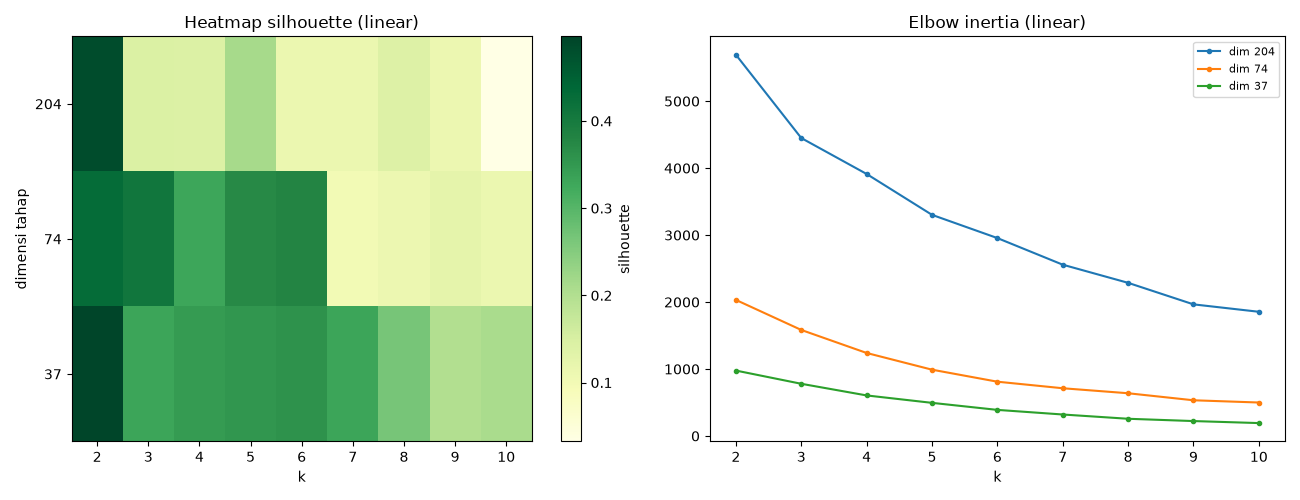

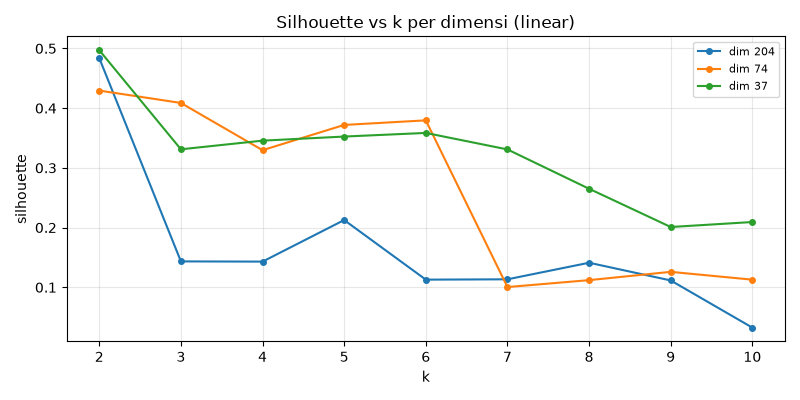

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

res = []
for d in LADDER:
    Xd = pd.read_csv(f"{OUT}/X_{TAG}_{d}.csv").to_numpy()
    for k in range(2, 11):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
        lab = km.fit_predict(Xd)
        sil = float(silhouette_score(Xd, lab))
        sizes = pd.Series(lab).value_counts().sort_index()
        res.append({"dimensi": d, "k": k, "silhouette": sil,
                    "inertia": float(km.inertia_), "seed": SEED,
                    "min_size": int(sizes.min()),
                    "ukuran_cluster": ";".join(map(str, sizes.tolist()))})
grid = pd.DataFrame(res)
grid.to_csv(f"{OUT}/clustering_grid_{TAG}.csv", index=False)
print(f"total konfigurasi: {len(grid)}")
print(grid.sort_values("silhouette", ascending=False).head(8).to_string(index=False))

valid = grid[grid["min_size"] >= 2].sort_values("silhouette", ascending=False)
print("\nTERBAIK VALID (min_size>=2):")
print(valid.head(5)[["dimensi", "k", "silhouette", "ukuran_cluster"]].to_string(index=False))

win = valid.iloc[0]
best = {"varian": TAG, "dimensi": int(win["dimensi"]), "k": int(win["k"]),
        "silhouette": float(win["silhouette"]), "inertia": float(win["inertia"]),
        "seed": SEED, "ukuran_cluster": str(win["ukuran_cluster"]),
        "aturan": "silhouette tertinggi dengan min_size>=2 (tanpa singleton)"}
with open(f"{OUT}/best_config_{TAG}.json", "w") as f:
    json.dump(best, f, indent=2)
dim_best = best["dimensi"]
Xd = pd.read_csv(f"{OUT}/X_{TAG}_{dim_best}.csv").to_numpy()
lab = KMeans(n_clusters=best["k"], random_state=SEED, n_init=10,
             max_iter=300).fit_predict(Xd)
pd.DataFrame({"daerah": dfm["daerah"].tolist(), "cluster": lab}).to_csv(
    f"{OUT}/labels_best_{TAG}.csv", index=False)
print("\nPEMENANG (diteruskan ke 5.7):", best)

piv = grid.pivot(index="dimensi", columns="k", values="silhouette").loc[LADDER]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im = axes[0].imshow(piv.to_numpy(), aspect="auto", cmap="YlGn")
axes[0].set_xticks(range(len(piv.columns))); axes[0].set_xticklabels(piv.columns)
axes[0].set_yticks(range(len(piv.index))); axes[0].set_yticklabels(piv.index)
axes[0].set_xlabel("k"); axes[0].set_ylabel("dimensi tahap")
axes[0].set_title(f"Heatmap silhouette ({TAG})")
fig.colorbar(im, ax=axes[0], label="silhouette")
for d in LADDER:
    gg = grid[grid["dimensi"] == d].sort_values("k")
    axes[1].plot(gg["k"], gg["inertia"], marker="o", ms=3, label=f"dim {d}")
axes[1].set_title(f"Elbow inertia ({TAG})"); axes[1].set_xlabel("k")
axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(f"{IMG}/fig_heatmap_elbow.png", dpi=100)
display(Image(filename=f"{IMG}/fig_heatmap_elbow.png"))

fig2, ax2 = plt.subplots(figsize=(8, 4))
for d in LADDER:
    gg = grid[grid["dimensi"] == d].sort_values("k")
    ax2.plot(gg["k"], gg["silhouette"], marker="o", ms=4, label=f"dim {d}")
ax2.set_xlabel("k"); ax2.set_ylabel("silhouette")
ax2.set_title(f"Silhouette vs k per dimensi ({TAG})")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
fig2.tight_layout(); fig2.savefig(f"{IMG}/fig_silhouette_per_dim.png", dpi=100)
display(Image(filename=f"{IMG}/fig_silhouette_per_dim.png"))


## Visualisasi — Diagram silhouette per sampel (pemenang)

Setiap batang = satu daerah. Batang panjang = sangat cocok di clusternya; pendek = ambigu.

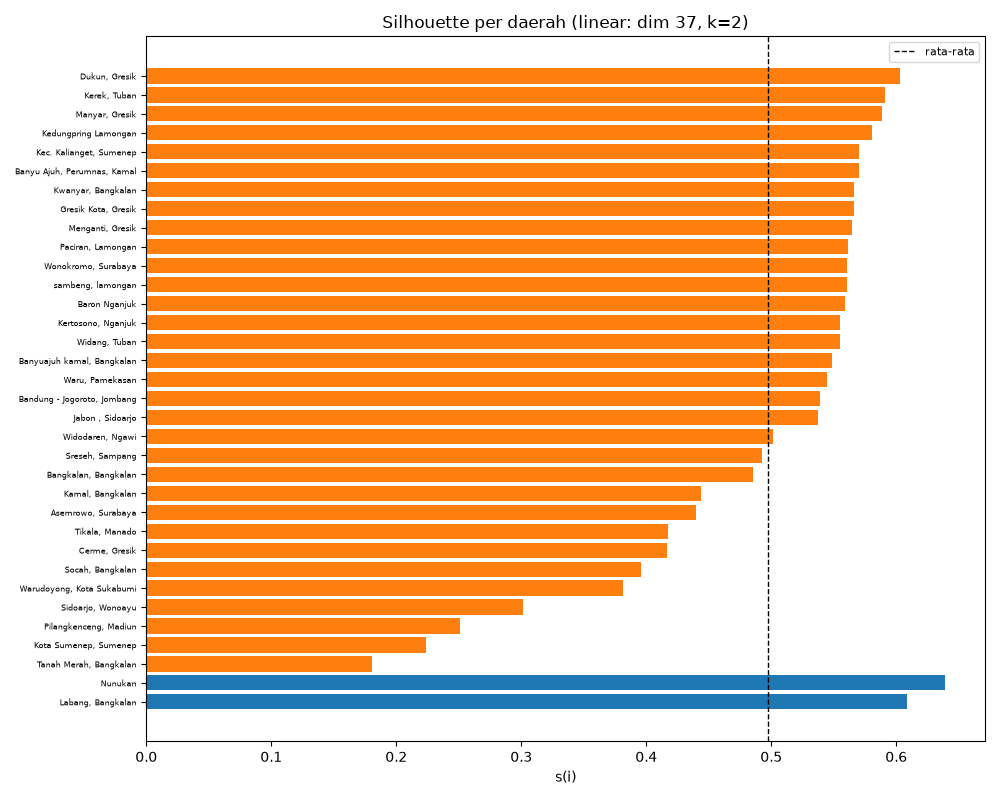

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

best = json.load(open("{}/best_config_{}.json".format(OUT, TAG)))
Xd = pd.read_csv("{}/X_{}_{}.csv".format(OUT, TAG, best['dimensi'])).to_numpy()
dfm = pd.read_csv("{}/clustering_{}_204.csv".format(OUT, TAG))
lab_best = KMeans(n_clusters=best['k'], random_state=SEED, n_init=10,
                  max_iter=300).fit_predict(Xd)
s_vals = silhouette_samples(Xd, lab_best)
order = np.argsort(lab_best * 100 + s_vals)
names = dfm["daerah"].tolist()
cmap = plt.get_cmap("tab10")
bar_colors = [cmap(int(lab_best[i]) % 10) for i in order]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(s_vals)), s_vals[order], color=bar_colors)
ax.axvline(s_vals.mean(), color="black", ls="--", lw=1, label="rata-rata")
ax.set_yticks(range(len(s_vals)))
ax.set_yticklabels([names[i] for i in order], fontsize=6)
ax.set_xlabel("s(i)")
ax.set_title("Silhouette per daerah ({}: dim {}, k={})".format(TAG, best['dimensi'], best['k']))
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("{}/fig_silhouette_samples.png".format(IMG), dpi=100)
display(Image(filename="{}/fig_silhouette_samples.png".format(IMG)))

## Visualisasi — Sebaran cluster di bidang PCA-2D + fitur pembeda

204 dimensi diringkas ke PC1 vs PC2 agar terlihat mata; diagram batang menunjukkan 10 fitur paling pembeda antar cluster pemenang.

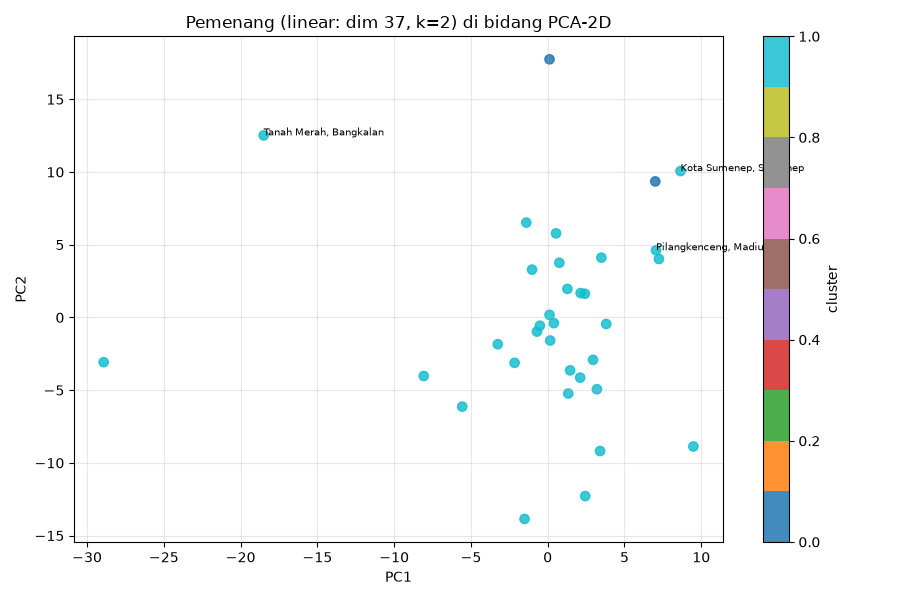

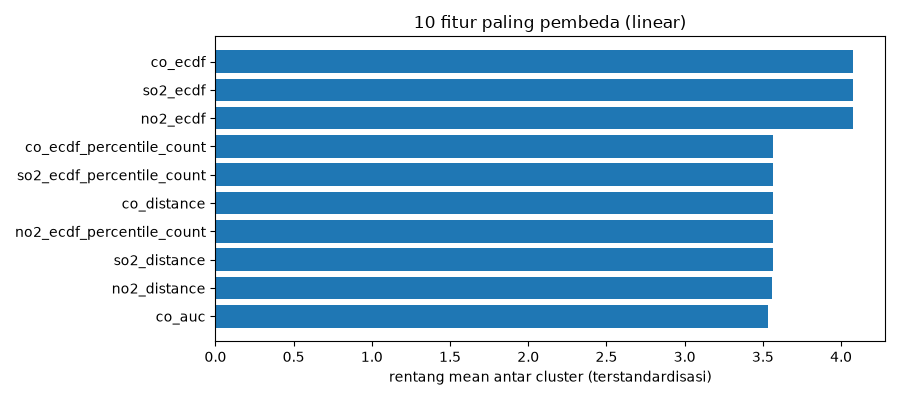

co_ecdf                      4.077155
so2_ecdf                     4.076851
no2_ecdf                     4.075307
co_ecdf_percentile_count     3.565994
so2_ecdf_percentile_count    3.565247
co_distance                  3.562930
no2_ecdf_percentile_count    3.562285
so2_distance                 3.562194
no2_distance                 3.558835
co_auc                       3.531528


In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Xm = StandardScaler().fit_transform(dfm[[c for c in dfm.columns if c != "daerah"]].to_numpy())
P2 = PCA(n_components=2, random_state=SEED).fit_transform(Xm)
kbest = len(set(lab_best))
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(P2[:, 0], P2[:, 1], c=lab_best, s=45, cmap="tab10", alpha=0.85)
fig.colorbar(sc, ax=ax, label="cluster")
for i in range(len(dfm)):
    if s_vals[i] < 0.3:
        ax.annotate(dfm.loc[i, "daerah"], (P2[i, 0], P2[i, 1]), fontsize=7)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Pemenang ({}: dim {}, k={}) di bidang PCA-2D".format(TAG, best['dimensi'], best['k']))
ax.grid(True, alpha=0.3)
fig.tight_layout(); fig.savefig("{}/fig_cluster_pca2d.png".format(IMG), dpi=100)
display(Image(filename="{}/fig_cluster_pca2d.png".format(IMG)))

means = [Xm[lab_best == k].mean(axis=0) for k in range(kbest)]
spread = pd.Series(np.max(means, axis=0) - np.min(means, axis=0),
                   index=[c for c in dfm.columns if c != "daerah"])
top = spread.sort_values(ascending=False).head(10)
fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.barh(top.index[::-1], top.values[::-1])
ax2.set_xlabel("rentang mean antar cluster (terstandardisasi)")
ax2.set_title("10 fitur paling pembeda ({})".format(TAG))
fig2.tight_layout(); fig2.savefig("{}/fig_top_pembeda.png".format(IMG), dpi=100)
display(Image(filename="{}/fig_top_pembeda.png".format(IMG)))
print(top.to_string())

## Kesimpulan dan cara menjalankan ulang

- Pemenang tersimpan di `data/processed/best_config_linear.json` + `labels_best_linear.csv` dan **dibaca notebook 5.7** (satu peta per varian).
- Tambah daerah ke file sumber lalu jalankan ulang: ladder, grid, saringan, dan peta ikut mutakhir.
- Pasangan notebook ini: `5.6a` = linear, `5.6b` = polynomial (`run_56ab.py` = versi skrip keduanya).